In [1]:
%reload_ext autoreload
%pylab inline
%autoreload 2
import numpy as np
from os.path import join
import sys
sys.path.insert(0, '/home/did/RTC/SMART-G/smartg/tools/')
from luts import LUT, MLUT, Idx, merge, plot_polar, read_mlut
from smacg import Smacg, get_smac_coeffs
import xarray
from datetime import datetime

/home/applis/anaconda/envs/py2v4.2/lib/python2.7/site-packages/matplotlib/font_manager.py:273: UserWarning: Matplotlib is building the font cache using fc-list. This may take a moment.
  warnings.warn('Matplotlib is building the font cache using fc-list. This may take a moment.')


Populating the interactive namespace from numpy and matplotlib


# DEM Read (once!)

In [3]:
# path to DEM
fdem = '/rfs/data/DEM/GTOPO30_MLUT.nc'
dem_lut = read_mlut(fdem) # global DEM GTOPO 30, reading once, could be long, stored into a MLUT object

In [4]:
# dem object is a MLUT object
dem_lut.describe()

 Datasets:
  [0] elev (uint16 in [0, 6.55e+04]), axes=('lat', 'lon')
 Axes:
  [0] lat: 21600 values in [90.0, -90.0]
  [1] lon: 43200 values in [-180.0, 180.0]


# SMACG configuration

In [5]:
# path to input VGT image (format hdf5)
fname = '/rfs/data/C3S/VGT/EXTRACT/2001/20010102/0_La_Crau_V120010102066.h5'
year  = fname[26:30]
date  = fname[31:39]
 
# path to input ancillary MERRA 2 data
# 1) aerosols
merra_aerosol='/rfs/data/MERRA2/aer_extinction/'+year+'/MERRA2_300.tavg1_2d_aer_Nx.'+date+'.SUB.nc4'
# 2) ozone
merra_ozone='/rfs/data/MERRA2/ozone/'+year+'/MERRA2_300.tavg1_2d_chm_Nx.'+date+'.SUB.nc4'
# 3) pressure
merra_pressure='/rfs/data/MERRA2/surf_pression/'+year+'/MERRA2_300.tavg1_2d_slv_Nx.'+date+'.SUB.nc4'
# 4) water vapour
merra_water='/rfs/data/MERRA2/total_precipitable_water_vapor/'+year+'/MERRA2_300.inst1_2d_int_Nx.'+date+'.SUB.nc4'

# VGT IMAGE SIZE
XSIZE = 49
YSIZE = 49
# VGT TIE POINTS SIZE
XTIE  = 7
YTIE  = 7

# GPU grid
XBLOCK = XSIZE
XGRID  = YSIZE
YGRID  = 1
YBLOCK = 1

M = XBLOCK * XGRID  # elemnentary size of pixel's array : match the GPU grid
Z      = 1 # eventually size of third dimension in the card
NBLOOP = 1 # eventually loops within card (for first version of smacg NLOOP=1)

sensor   = 'VGT2'  # Effective sensor
aer_coef = 'CONT'  # 'CONT' or 'DES' SMAC aerosol coefficient
tab_band = ['B0', 'B2', 'B3', 'MIR']  # List bands here
NB = len(tab_band)  # number of bands
dir_coef_name = './' # directory containing SMAC Coefficients


### Constants
version = '0.0.3'
Hatm   = 8000. # molecular scale height (m)
c_p0   = 1012.15  # 1 atm
k_uh2o = 1e-1  # conversion from kg.m-2 to g.cm-2
k_uo3  = 1e-3  # (for MERRA-2, Dobson) to cm.atm
k_p0   = 1e-2  # pascal vers hectopascal

# Error budget (TBD, here just for tests)
Etoa   = 0    # bias toa reflectance
ERtoa  = 0.01 # precision toa reflectance (in %)
Etaup  = 0.05
ERtaup = 0.1
Euo3   = 0.01
ERuo3  = 0.02
Euh2o  = 0.1
ERuh2o = 0.05
Epre   = 5.
ERpre  = 0.02
  
# compile Smacg 
S=Smacg()

#  VGT preprocessing

In [6]:
from scipy.interpolate import RectBivariateSpline

def get_meantime(dataset):
    date = dataset.segm_first_date
    time = dataset.segm_first_time
    dt1  = np.datetime64(str(date[:4]) + '-' + str(date[4:6]) + \
                        '-' + str(date[6:])+ 'T' +  str(time[:2]) + \
                         ':' + str(time[2:4])+ ':' + str(time[4:]))
    time = dataset.segm_last_time
    dt2  = np.datetime64(str(date[:4]) + '-' + str(date[4:6]) + \
                        '-' + str(date[6:])+ 'T' +  str(time[:2]) + \
                         ':' + str(time[2:4])+ ':' + str(time[4:]))

    return ((dt2-dt1)/2. +dt1)

def datetime2year(dt): 
    year_part = dt - datetime(year=dt.year, month=1, day=1)
    year_length = datetime(year=dt.year+1, month=1, day=1) - datetime(year=dt.year, month=1, day=1)
    return dt.year + year_part/year_length

def to_float (dataset, elem):
    res = dataset[elem] = dataset[elem] * float(dataset[elem].attrs['Scale']) + float(dataset[elem].attrs['Offset'])
    return res

def date_to_float(d, epoch=numpy.datetime64('2000-01-01T00:00:00.000000000')):
    return (d - epoch)

def pre(fname):
    dataset = xarray.open_dataset(fname)

    lon0, lat0, d_lon, d_lat = [float(x) for x in dataset.map_info.split(',')[3:7]]

    lat=lat0 - arange(XSIZE)*d_lat
    lon=lon0 + arange(YSIZE)*d_lon
    lat,lon=np.meshgrid(lat,lon)
    dataset['lat']=(('x', 'y'), lat)
    dataset['lon']=(('x', 'y'), lon)
     
    # preprocessing of VGT file to fill lat and lon to XSIZE and YSIZE
    # This maybe unnecessary in the future if lat and lon are given for each pixel of VGT
    VGT_TIE_COMPLETE(dataset,'SZA')
    VGT_TIE_COMPLETE(dataset,'SAA')
    VGT_TIE_COMPLETE(dataset,'VZA')
    VGT_TIE_COMPLETE(dataset,'VAA')
    
    # scale reflectances
    to_float(dataset,'B0')
    to_float(dataset,'B2')
    to_float(dataset,'B3')
    to_float(dataset,'MIR')
    
    # mean decimal time for the scene
    dataset['mean-time']= get_meantime(dataset)
    #dataset['mean-time-dec']= date_to_float(dataset['mean-time'].data)
    dataset['mean-time-dec']= 9.5
    
    return dataset


def VGT_TIE_COMPLETE (dataset,a):
    machin = dataset[a] * float(dataset[a].attrs['Scale']) + float(dataset[a].attrs['Offset'])
    r1=np.arange(0,XSIZE,XTIE)
    r11,_=np.meshgrid(np.arange(XSIZE),np.arange(YSIZE))
    r2=np.arange(0,YSIZE,YTIE)
    _,r22=np.meshgrid(np.arange(XSIZE),np.arange(YSIZE))
    res = RectBivariateSpline(r1,r2,machin).ev(r11,r22)
    res = xarray.DataArray(res,dims = ('phony_dim_0', 'phony_dim_0'))
    
    dataset.drop(a)
    dataset[a] = res

vgt_data = pre(fname)

# MERRA2 preprocessing

In [7]:
# Read MERRA2 ancillary data files and store all information into a MLUT object for further use
# (mainly for spatial and temporal interpolation)
merra = xarray.open_dataset(merra_aerosol)
merra_lut = MLUT()
# Add the good axis
#merra_lut.add_axis('time', date_to_float(merra.time.data))
merra_lut.add_axis('time', np.linspace(0.5, 23.5, num=24))
merra_lut.add_axis('lat',  merra.lat.data)
merra_lut.add_axis('lon',  merra.lon.data)

sds=['BCEXTTAU','DUEXTTAU','DUEXTT25','OCEXTTAU','SSEXTT25','SSEXTTAU','SUEXTTAU','TOTANGSTR','TOTEXTTAU','TOTSCATAU']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
###same for other MERRA2 parameters
merra = xarray.open_dataset(merra_ozone)
sds=['TO3']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
merra = xarray.open_dataset(merra_pressure)
sds=['SLP']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])

merra = xarray.open_dataset(merra_water)
sds=['TQV']
for sd in sds:
    merra_lut.add_dataset(sd, merra[sd].data, axnames=['time','lat','lon'])
    
# show MLUT description
merra_lut.describe()

 Datasets:
  [0] BCEXTTAU (float64 in [0.00023, 0.177]), axes=('time', 'lat', 'lon')
  [1] DUEXTTAU (float64 in [5.9e-05, 1.23]), axes=('time', 'lat', 'lon')
  [2] DUEXTT25 (float64 in [4.33e-05, 0.644]), axes=('time', 'lat', 'lon')
  [3] OCEXTTAU (float64 in [0.000361, 0.752]), axes=('time', 'lat', 'lon')
  [4] SSEXTT25 (float64 in [2.16e-05, 0.762]), axes=('time', 'lat', 'lon')
  [5] SSEXTTAU (float64 in [2.54e-05, 1.93]), axes=('time', 'lat', 'lon')
  [6] SUEXTTAU (float64 in [0.00352, 1.48]), axes=('time', 'lat', 'lon')
  [7] TOTANGSTR (float64 in [-0.0306, 1.95]), axes=('time', 'lat', 'lon')
  [8] TOTEXTTAU (float64 in [0.00653, 2.14]), axes=('time', 'lat', 'lon')
  [9] TOTSCATAU (float64 in [0.00621, 2.14]), axes=('time', 'lat', 'lon')
  [10] TO3 (float64 in [213, 486]), axes=('time', 'lat', 'lon')
  [11] SLP (float64 in [9.5e+04, 1.06e+05]), axes=('time', 'lat', 'lon')
  [12] TQV (float64 in [0.146, 76.8]), axes=('time', 'lat', 'lon')
 Axes:
  [0] time: 24 values in [0.5, 23.5]


# SMAC-G preparation of data

In [10]:
# files containg SMAC coefficients
bands_path = ["".join((dir_coef_name, 'COEFFS/coef_' + sensor + '_' + str(x) + '_' + aer_coef + '.dat')) for x in tab_band]

# start with tie points
tetas       = vgt_data['SZA'].data.astype(float32, order='C')
tetav       = vgt_data['VZA'].data.astype(float32, order='C')
phis        = vgt_data['SAA'].data.astype(float32, order='C')
phiv        = vgt_data['VAA'].data.astype(float32, order='C')

#interpolate merra 2 data and dem to the image location and time
taup550     = merra_lut['TOTEXTTAU']\
                [Idx(vgt_data['mean-time-dec'].data, round=False),Idx(vgt_data['lat'].data,round=False),\
                 Idx(vgt_data['lon'].data,round=False)]\
                .astype(float32, order='C') 
uh2o        = merra_lut['TQV']\
                [Idx(vgt_data['mean-time-dec'].data, round=False),Idx(vgt_data['lat'].data,round=False),\
                 Idx(vgt_data['lon'].data,round=False)]\
                .astype(float32, order='C')
uo3         = merra_lut['TO3']\
                [Idx(vgt_data['mean-time-dec'].data, round=False),Idx(vgt_data['lat'].data,round=False),\
                 Idx(vgt_data['lon'].data,round=False)]\
                .astype(float32, order='C')
pressure    = merra_lut['SLP']\
                [Idx(vgt_data['mean-time-dec'].data, round=False),Idx(vgt_data['lat'].data,round=False),\
                 Idx(vgt_data['lon'].data,round=False)]\
                .astype(float32, order='C')
alt         = np.array((dem_lut['elev']*1.)\
                [Idx(vgt_data['lat'].data,round=False),\
                 Idx(vgt_data['lon'].data,round=False)])\
                .astype(float32, order='C')

# pressure correction for surface altitude and transformation from Pa to hPa
pressure *= np.exp(-alt/Hatm) * k_p0
# conversion from kg.m-2 to g.cm-2
uh2o *= k_uh2o
# conversion from Dobson to cm.atm 
uo3  *= k_uo3

# prepare radiometry array
rtoa    = np.zeros((NB, YSIZE, XSIZE), dtype='float32', order='C')

for iband, band in enumerate(tab_band):
    rtoa[iband,:,:] = vgt_data[band].data

# Inputs arrays reshaping
rtoa_in    = np.reshape(rtoa,(NB,Z,XBLOCK,XGRID), order='C')

# Getting SMAC coefficients
coeffs     = get_smac_coeffs(bands_path)

# Processing by the GPU

In [11]:
%%time
# Run
(rsurf,Jrtoa,Juo3,Juh2o,Jpre,Jtaup) = S.run(coeffs, tetas, tetav, phis, phiv,
        uh2o, uo3, taup550, pressure, rtoa_in,
        XBLOCK=XBLOCK, XGRID=XGRID, NBLOOP=NBLOOP)

CPU times: user 70.3 ms, sys: 124 ms, total: 195 ms
Wall time: 4.73 s


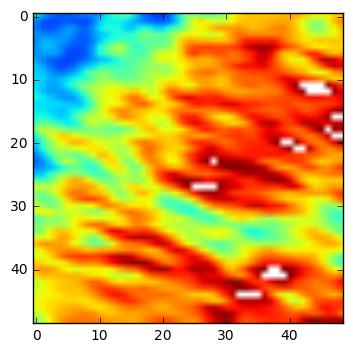

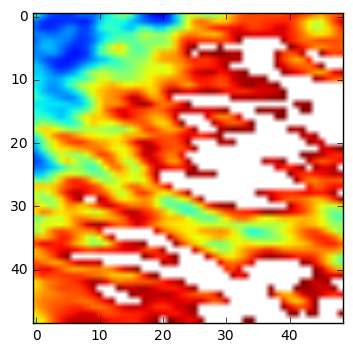

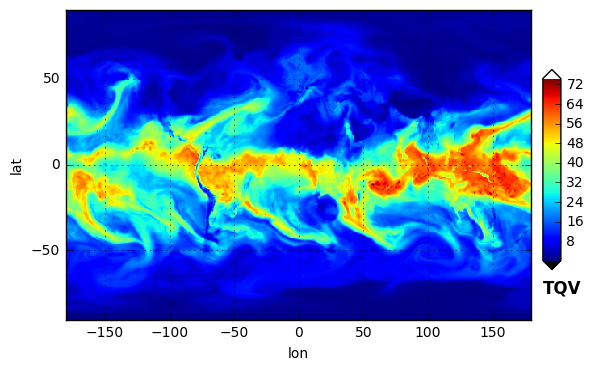

In [12]:
rsurf=rsurf.reshape((NB, XSIZE, YSIZE),order='C')
figure()
imshow(rtoa[1,:,:],vmax=.8,vmin=0)
figure()
imshow(rsurf[1,:,:],vmax=.8,vmin=0)
figure()

merra_lut['TQV'].sub()[Idx(12),:,:].plot()